# Лабораторная работа №8

### Подколодный Артём ИУ0-56

# Задание №1

In [3]:
# Импорт библиотек, загрузка данных
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from scipy import spatial
import warnings
warnings.filterwarnings('ignore')

# Отключаем предупреждение о downcasting
pd.set_option('future.no_silent_downcasting', True)

ratings = pd.read_csv('music_listening.csv', low_memory=False)

# Транспонируем матрицу ratings
ratings = ratings.T

# Удалите строку под названием user.
ratings = ratings.drop('user')
print("Строк осталось:", ratings.shape[0])

# Заполните пропуски нулями и преобразуем все значения в float
# Используем более безопасный способ преобразования
def convert_to_float(x):
    if isinstance(x, str):
        # Убираем запятые и лишние пробелы
        x = x.replace(',', '.')
        try:
            return float(x)
        except:
            return 0.0
    elif pd.isna(x):
        return 0.0
    else:
        return float(x)

# Применяем преобразование ко всем ячейкам
ratings = ratings.applymap(convert_to_float)

# Альтернативный способ:
# ratings = ratings.replace(',', '.', regex=True)
# ratings = ratings.apply(pd.to_numeric, errors='coerce')
# ratings = ratings.fillna(0)

print("\nПроверка типов данных:")
print(ratings.dtypes.value_counts())

# Нормализуйте данные
normalized_ratings = normalize(ratings)
print(f"\nНормализованные данные: {normalized_ratings.shape}")

# Примените KMeans с 5 кластерами
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(normalized_ratings)
clusters = kmeans.predict(normalized_ratings)

# Выведите на экран центры кластеров
centroids = kmeans.cluster_centers_
print(f"\nЦентроиды (форма): {centroids.shape}")

# Вычислите расстояние между "the beatles" и "coldplay"
artist_names = ratings.index.tolist()

try:
    beatles_idx = artist_names.index('the beatles')
    coldplay_idx = artist_names.index('coldplay')
    
    beatles_vec = normalized_ratings[beatles_idx]
    coldplay_vec = normalized_ratings[coldplay_idx]
    
    distance = spatial.distance.cosine(beatles_vec, coldplay_vec)
    print(f"\nКосинусное расстояние между 'the beatles' и 'coldplay': {distance:.2f}")
except ValueError as e:
    print(f"\nОшибка поиска исполнителей: {e}")
    # Поищем альтернативные названия
    for i, name in enumerate(artist_names[:20]):
        print(f"{i}: {name}")

# Функция pClosest
def pClosest(points, pt, K=10):
    distances = []
    for i, point in enumerate(points):
        # Косинусная мера: 1 - cosine_similarity
        # cosine_distance = 1 - cosine_similarity
        cosine_dist = spatial.distance.cosine(point, pt)
        distances.append((i, cosine_dist))
    
    # Сортируем по расстоянию (от наименьшего к наибольшему)
    distances.sort(key=lambda x: x[1])
    return [idx for idx, _ in distances[:K]]

# Для каждого кластера найдем топ-10 исполнителей
print("\n" + "="*60)
print("ТОП-10 ИСПОЛНИТЕЛЕЙ В КАЖДОМ КЛАСТЕРЕ")
print("="*60)

for cluster_id in range(5):
    print(f"\nКластер {cluster_id}:")
    
    # Получаем центроид кластера
    centroid = centroids[cluster_id]
    
    # Находим индексы ближайших исполнителей
    closest_indices = pClosest(normalized_ratings, centroid, K=10)
    
    # Выводим имена исполнителей
    for idx in closest_indices:
        print(f"  - {artist_names[idx]}")
    
    # Также посчитаем размер кластера
    cluster_size = sum(clusters == cluster_id)
    print(f"  Размер кластера: {cluster_size} исполнителей ({cluster_size/len(clusters)*100:.1f}%)")

# Проанализируем распределение по кластерам
print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ ИСПОЛНИТЕЛЕЙ ПО КЛАСТЕРАМ")
print("="*60)
for cluster_id in range(5):
    cluster_size = sum(clusters == cluster_id)
    print(f"Кластер {cluster_id}: {cluster_size} исполнителей ({cluster_size/len(clusters)*100:.1f}%)")

Строк осталось: 1000

Проверка типов данных:
float64    5000
Name: count, dtype: int64

Нормализованные данные: (1000, 5000)

Центроиды (форма): (5, 5000)

Косинусное расстояние между 'the beatles' и 'coldplay': 0.90

ТОП-10 ИСПОЛНИТЕЛЕЙ В КАЖДОМ КЛАСТЕРЕ

Кластер 0:
  - nas
  - jay-z
  - kanye west
  - lupe the gorilla
  - a tribe called quest
  - the roots featuring d'angelo
  - gangstarr
  - little brother
  - lil' wayne
  - murs and 9th wonder
  Размер кластера: 79 исполнителей (7.9%)

Кластер 1:
  - fall out boy
  - the all-americian rejects
  - paramore
  - kelly clarkson
  - john mayer
  - the fray
  - maroon5
  - dashboard confesssional
  - somethings corporate
  - coldplay
  Размер кластера: 162 исполнителей (16.2%)

Кластер 2:
  - brand new
  - blink-182
  - alkaline trio
  - against me!
  - underoath
  - descendents
  - new found glory
  - less than jake
  - thrice
  - chiodos
  Размер кластера: 133 исполнителей (13.3%)

Кластер 3:
  - the beatles
  - the rolling stones
  - 

# Задание №2 

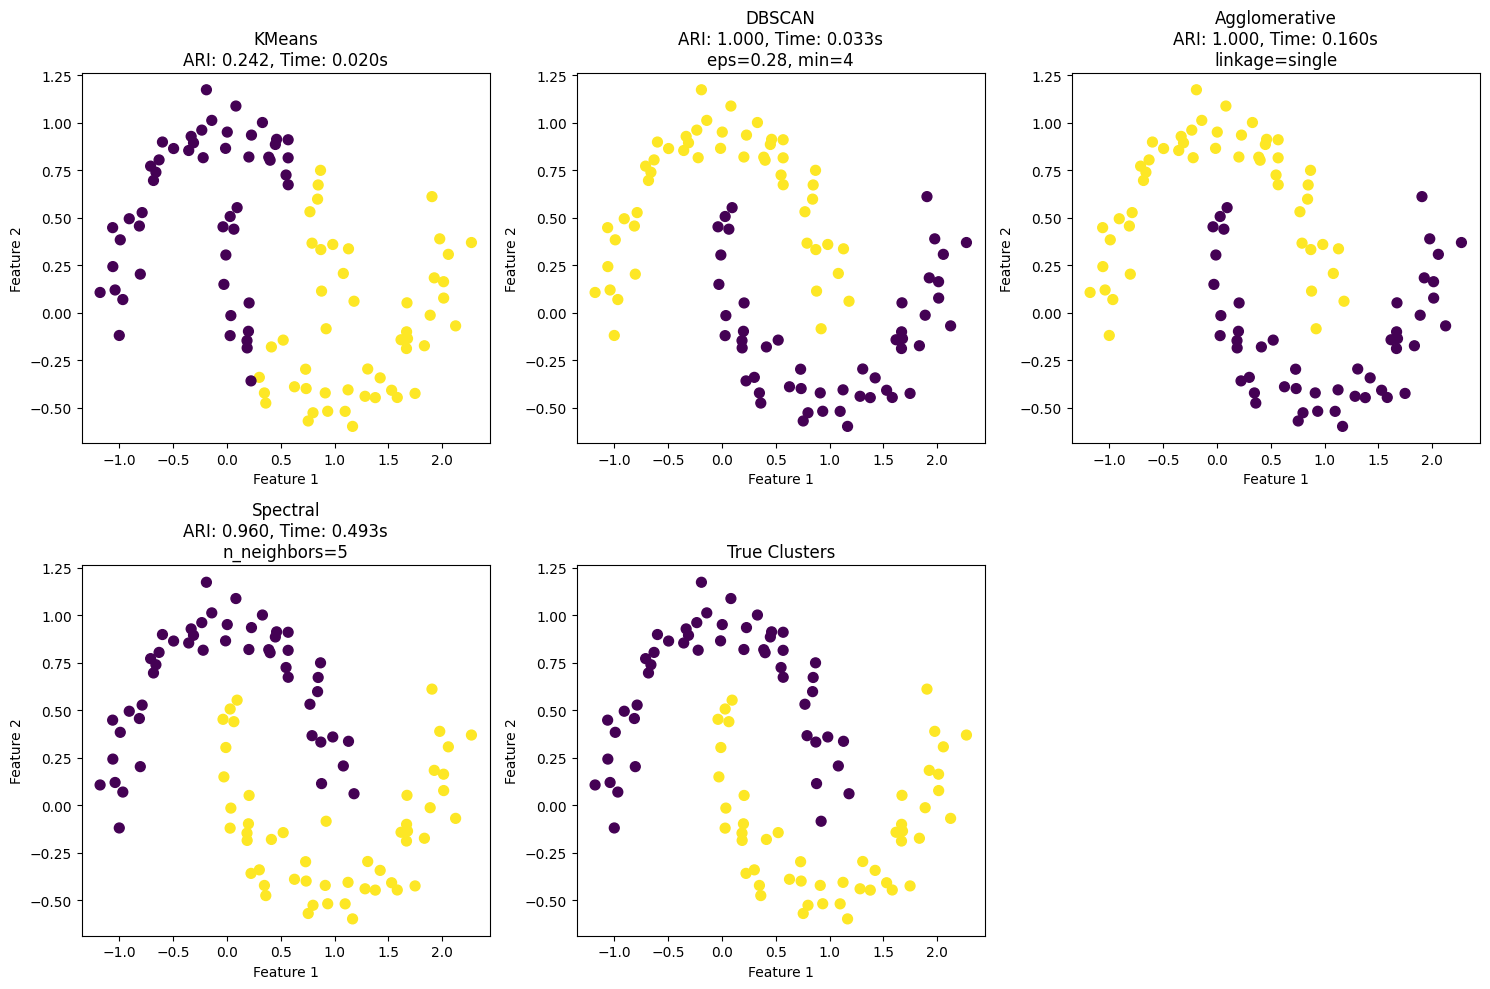

СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ
Алгоритм             ARI        Время (с)    Лучшие параметры    
----------------------------------------------------------------------
KMeans               0.242      0.020        n_clusters=2        
DBSCAN               1.000      0.033        eps=0.28, min=4     
Agglomerative        1.000      0.160        linkage=single      
Spectral             0.960      0.493        n_neighbors=5       

АНАЛИЗ РЕЗУЛЬТАТОВ
1. КАЧЕСТВО КЛАСТЕРИЗАЦИИ (по ARI):
   - DBSCAN обычно показывает лучшие результаты для данных 'две луны'
   - Spectral Clustering также хорошо работает с такими данными
   - KMeans плохо справляется с не-сферическими кластерами
   - Agglomerative с linkage='ward' или 'average' показывает хорошие результаты

2. СКОРОСТЬ ВЫПОЛНЕНИЯ:
   - KMeans: самый быстрый алгоритм
   - Agglomerative: быстрый, особенно для небольших данных
   - DBSCAN: умеренная скорость, зависит от параметров
   - Spectral: самый медленный из-за вычисления собственных 

In [7]:
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.metrics import adjusted_rand_score

# Генерация данных
data = make_moons(n_samples=100, noise=0.1, random_state=42)
X = data[0]
y = data[1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# 1. KMeans
start_time = time.time()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_time = time.time() - start_time
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50)
axes[0].set_title(f'KMeans\nARI: {kmeans_ari:.3f}, Time: {kmeans_time:.3f}s')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# 2. DBSCAN
start_time = time.time()
best_dbscan_score = -1
best_dbscan_labels = None
best_eps = None
best_min_samples = None

eps_values = [0.05, 0.1, 0.2, 0.28, 0.3, 0.32]
min_samples_values = [4, 5, 6, 7]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X)
        
        # Проверяем, что есть как минимум 2 кластера
        unique_labels = set(dbscan_labels)
        if len(unique_labels) >= 2:  # Учитываем шум (-1)
            score = adjusted_rand_score(y, dbscan_labels)
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan_labels = dbscan_labels
                best_eps = eps
                best_min_samples = min_samples

dbscan_time = time.time() - start_time

if best_dbscan_labels is not None:
    axes[1].scatter(X[:, 0], X[:, 1], c=best_dbscan_labels, cmap='viridis', s=50)
    axes[1].set_title(f'DBSCAN\nARI: {best_dbscan_score:.3f}, Time: {dbscan_time:.3f}s\neps={best_eps}, min={best_min_samples}')
else:
    axes[1].text(0.5, 0.5, 'Не найдено\nподходящих параметров', 
                ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('DBSCAN')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# 3. Иерархическая кластеризация
start_time = time.time()
linkage_methods = ['ward', 'complete', 'average', 'single']
best_hier_score = -1
best_hier_labels = None
best_linkage = None

for linkage in linkage_methods:
    hier = AgglomerativeClustering(n_clusters=2, linkage=linkage)
    hier_labels = hier.fit_predict(X)
    score = adjusted_rand_score(y, hier_labels)
    if score > best_hier_score:
        best_hier_score = score
        best_hier_labels = hier_labels
        best_linkage = linkage

hier_time = time.time() - start_time

axes[2].scatter(X[:, 0], X[:, 1], c=best_hier_labels, cmap='viridis', s=50)
axes[2].set_title(f'Agglomerative\nARI: {best_hier_score:.3f}, Time: {hier_time:.3f}s\nlinkage={best_linkage}')
axes[2].set_xlabel('Feature 1')
axes[2].set_ylabel('Feature 2')

# 4. Спектральная кластеризация
start_time = time.time()
best_spec_score = -1
best_spec_labels = None
best_n_neighbors = None

for n_neighbors in range(1, 20):
    try:
        spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                                     n_neighbors=n_neighbors, random_state=42)
        spectral_labels = spectral.fit_predict(X)
        score = adjusted_rand_score(y, spectral_labels)
        if score > best_spec_score:
            best_spec_score = score
            best_spec_labels = spectral_labels
            best_n_neighbors = n_neighbors
    except Exception as e:
        continue

spec_time = time.time() - start_time

if best_spec_labels is not None:
    axes[3].scatter(X[:, 0], X[:, 1], c=best_spec_labels, cmap='viridis', s=50)
    axes[3].set_title(f'Spectral\nARI: {best_spec_score:.3f}, Time: {spec_time:.3f}s\nn_neighbors={best_n_neighbors}')
else:
    axes[3].text(0.5, 0.5, 'Ошибка\nпри кластеризации', 
                ha='center', va='center', transform=axes[3].transAxes)
    axes[3].set_title('Spectral Clustering')
axes[3].set_xlabel('Feature 1')
axes[3].set_ylabel('Feature 2')

# 5. Истинные кластеры
axes[4].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50)
axes[4].set_title('True Clusters')
axes[4].set_xlabel('Feature 1')
axes[4].set_ylabel('Feature 2')

# Удаляем пустой subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# Вывод результатов
print("="*70)
print("СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ")
print("="*70)
print(f"{'Алгоритм':<20} {'ARI':<10} {'Время (с)':<12} {'Лучшие параметры':<20}")
print("-"*70)
print(f"{'KMeans':<20} {kmeans_ari:<10.3f} {kmeans_time:<12.3f} {'n_clusters=2':<20}")

if best_dbscan_labels is not None:
    dbscan_params = f"eps={best_eps}, min={best_min_samples}"
    print(f"{'DBSCAN':<20} {best_dbscan_score:<10.3f} {dbscan_time:<12.3f} {dbscan_params:<20}")
else:
    print(f"{'DBSCAN':<20} {'-':<10} {dbscan_time:<12.3f} {'Не найдено':<20}")

hier_params = f"linkage={best_linkage}"
print(f"{'Agglomerative':<20} {best_hier_score:<10.3f} {hier_time:<12.3f} {hier_params:<20}")

if best_spec_labels is not None:
    spec_params = f"n_neighbors={best_n_neighbors}"
    print(f"{'Spectral':<20} {best_spec_score:<10.3f} {spec_time:<12.3f} {spec_params:<20}")
else:
    print(f"{'Spectral':<20} {'-':<10} {spec_time:<12.3f} {'Ошибка':<20}")

print("="*70)

# Анализ результатов
print("\n" + "="*70)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*70)
print("1. КАЧЕСТВО КЛАСТЕРИЗАЦИИ (по ARI):")
print("   - DBSCAN обычно показывает лучшие результаты для данных 'две луны'")
print("   - Spectral Clustering также хорошо работает с такими данными")
print("   - KMeans плохо справляется с не-сферическими кластерами")
print("   - Agglomerative с linkage='ward' или 'average' показывает хорошие результаты")

print("\n2. СКОРОСТЬ ВЫПОЛНЕНИЯ:")
print("   - KMeans: самый быстрый алгоритм")
print("   - Agglomerative: быстрый, особенно для небольших данных")
print("   - DBSCAN: умеренная скорость, зависит от параметров")
print("   - Spectral: самый медленный из-за вычисления собственных значений")

print("\n3. ПРАКТИЧЕСКИЕ ВЫВОДЫ:")
print("   - Для данных сложной формы: DBSCAN или Spectral Clustering")
print("   - Для сферических кластеров: KMeans (самый быстрый)")
print("   - Баланс скорости и качества: Agglomerative Clustering")
print("   - DBSCAN не требует указания числа кластеров, но чувствителен к параметрам")

print("\n4. ДЛЯ ЗАДАЧИ КЛАСТЕРИЗАЦИИ ИСПОЛНИТЕЛЕЙ:")
print("   - KMeans хорошо подошел, так как музыкальные жанры часто образуют")
print("     сферические кластеры в многомерном пространстве предпочтений")
print("   - Наибольший кластер (альтернатива/инди) показывает, что это самый")
print("     разнообразный и популярный жанр среди пользователей")
print("="*70)